In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils

# Reading chains

In [43]:
### 2PT ONLY
# analytic covariance, no compression
s_2pt = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-run/des-y3-2pt.txt', to_mcsamples=True, blind=False)
# simulation based covariance, no compression
s_2pt_sim = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-run/des-y3-2pt-400simcov.txt', to_mcsamples=True, blind=False)
# analytic covariance for compression, simulation based covariance for likelihood
s_2pt_moped= utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-moped-run/des-y3-2pt-400simcov.txt', to_mcsamples=True, blind=False)

### JOINT
s_joint = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=False)
s_joint_auto = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-auto.txt', to_mcsamples=True, blind=False)

### BARYON
s_baryon = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-baryon-run/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=False)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


## Plotting
### Validation of 2pt compression

<Figure size 600x600 with 0 Axes>

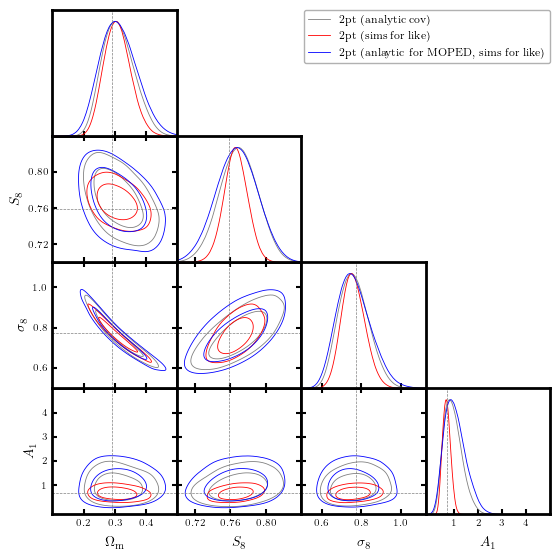

In [6]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt, s_2pt_sim, s_2pt_moped], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt (analytic cov)', '2pt (sims for like)',  '2pt (anlaytic for MOPED, sims for like)'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'blue'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

### Improvement with map3

<Figure size 600x600 with 0 Axes>

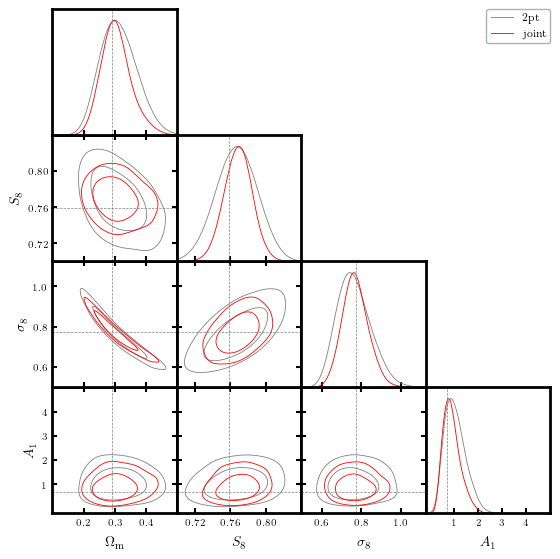

In [45]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt_moped, s_joint], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt', 'joint'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

In [37]:
fom_2pt = utils.FoM_from_samples_names(s_2pt_moped, ['om', 's8', 'a1'])
fom_joint = utils.FoM_from_samples_names(s_joint, ['om', 's8', 'a1'])

print(fom_2pt, fom_joint)
print(fom_joint/fom_2pt)

1953.907652586025 3756.396490091878
1.9225046204820546


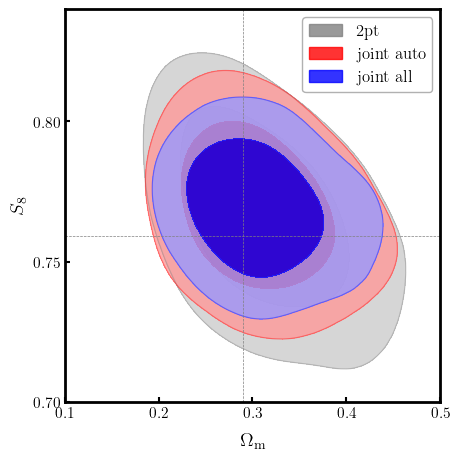

In [56]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([s_2pt_moped, s_joint_auto, s_joint], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'blue'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['2pt', 'joint auto', 'joint all'], legend_loc='upper right')
g.add_x_marker(0.29)
g.add_y_marker(0.759)

#### Baryon effect

<Figure size 600x600 with 0 Axes>

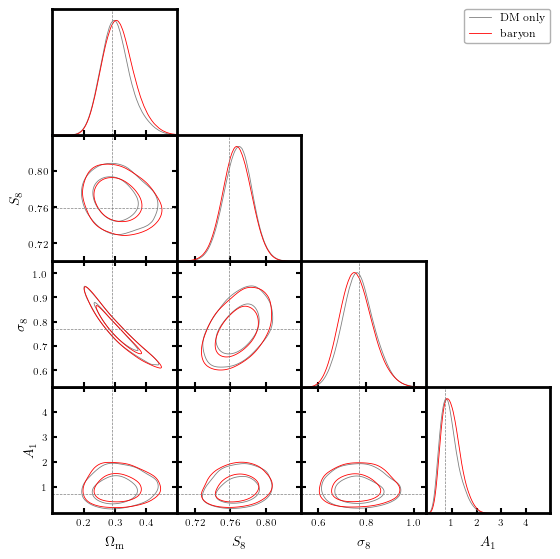

In [41]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_joint, s_baryon], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['DM only', 'baryon'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()